In [1]:
import pandas as pd

In [2]:
df = pd.read_csv(r"C:\Users\Admin\OneDrive\Documents\Sales Analysis\Global_Superstore2.csv", encoding='latin-1')

In [3]:
df

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,32298,CA-2012-124891,31-07-2012,31-07-2012,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,...,TEC-AC-10003033,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,2309.650,7,0.0,762.1845,933.57,Critical
1,26341,IN-2013-77878,05-02-2013,07-02-2013,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,...,FUR-CH-10003950,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.7650,923.63,Critical
2,25330,IN-2013-71249,17-10-2013,18-10-2013,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,...,TEC-PH-10004664,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171,9,0.1,919.9710,915.49,Medium
3,13524,ES-2013-1579342,28-01-2013,30-01-2013,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,...,TEC-PH-10004583,Technology,Phones,"Motorola Smart Phone, Cordless",2892.510,5,0.1,-96.5400,910.16,Medium
4,47221,SG-2013-4320,05-11-2013,06-11-2013,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,Dakar,...,TEC-SHA-10000501,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.960,8,0.0,311.5200,903.04,Critical
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51285,29002,IN-2014-62366,19-06-2014,19-06-2014,Same Day,KE-16420,Katrina Edelman,Corporate,Kure,Hiroshima,...,OFF-FA-10000746,Office Supplies,Fasteners,"Advantus Thumb Tacks, 12 Pack",65.100,5,0.0,4.5000,0.01,Medium
51286,35398,US-2014-102288,20-06-2014,24-06-2014,Standard Class,ZC-21910,Zuschuss Carroll,Consumer,Houston,Texas,...,OFF-AP-10002906,Office Supplies,Appliances,Hoover Replacement Belt for Commercial Guardsm...,0.444,1,0.8,-1.1100,0.01,Medium
51287,40470,US-2013-155768,02-12-2013,02-12-2013,Same Day,LB-16795,Laurel Beltran,Home Office,Oxnard,California,...,OFF-EN-10001219,Office Supplies,Envelopes,"#10- 4 1/8"" x 9 1/2"" Security-Tint Envelopes",22.920,3,0.0,11.2308,0.01,High
51288,9596,MX-2012-140767,18-02-2012,22-02-2012,Standard Class,RB-19795,Ross Baird,Home Office,Valinhos,São Paulo,...,OFF-BI-10000806,Office Supplies,Binders,"Acco Index Tab, Economy",13.440,2,0.0,2.4000,0.00,Medium


In [4]:
# 1. Data Cleaning
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          51290 non-null  int64  
 1   Order ID        51290 non-null  str    
 2   Order Date      51290 non-null  str    
 3   Ship Date       51290 non-null  str    
 4   Ship Mode       51290 non-null  str    
 5   Customer ID     51290 non-null  str    
 6   Customer Name   51290 non-null  str    
 7   Segment         51290 non-null  str    
 8   City            51290 non-null  str    
 9   State           51290 non-null  str    
 10  Country         51290 non-null  str    
 11  Postal Code     9994 non-null   float64
 12  Market          51290 non-null  str    
 13  Region          51290 non-null  str    
 14  Product ID      51290 non-null  str    
 15  Category        51290 non-null  str    
 16  Sub-Category    51290 non-null  str    
 17  Product Name    51290 non-null  str    
 1

In [5]:
df.isnull().sum()

Row ID                0
Order ID              0
Order Date            0
Ship Date             0
Ship Mode             0
Customer ID           0
Customer Name         0
Segment               0
City                  0
State                 0
Country               0
Postal Code       41296
Market                0
Region                0
Product ID            0
Category              0
Sub-Category          0
Product Name          0
Sales                 0
Quantity              0
Discount              0
Profit                0
Shipping Cost         0
Order Priority        0
dtype: int64

In [6]:
# No need to postal code as we have city names
df.drop("Postal Code", axis = 1, inplace = True)

In [7]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
City              0
State             0
Country           0
Market            0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
Shipping Cost     0
Order Priority    0
dtype: int64

In [8]:
# Converting str to datetime
df["Order Date"] = pd.to_datetime(df["Order Date"])

C:\Users\Admin\AppData\Local\Temp\ipykernel_9212\383411716.py:2: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["Order Date"] = pd.to_datetime(df["Order Date"])


In [9]:
# 2. Finding MoM growth
# Extracting month and year from datetime
# df["Order Week"] = df["Order Week"].dt.to_period("W")    # for weekly
df["Order Month"] = df["Order Date"].dt.to_period("M")    # for monthly
# df["Order Quaterly"] = df["Order Quaterly"].dt.to_period("Q")    # for Quaterly
# df["Order Year"] = df["Order Year"].dt.to_period("Y")     # for yearly

# for a specific date or month or year 
# df["order Date"] = df["order Date"].dt.day_name("Wednesday")  # gives wednesday data only
# df["order Month"] = df["order Month"].dt.month_name("January")  # gives January data only
# df["order Hour"] = df["order Hour"].dt.hour                     # gives hourly data only



In [10]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority,Order Month
0,32298,CA-2012-124891,2012-07-31,31-07-2012,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,...,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,2309.650,7,0.0,762.1845,933.57,Critical,2012-07
1,26341,IN-2013-77878,2013-02-05,07-02-2013,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,...,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.7650,923.63,Critical,2013-02
2,25330,IN-2013-71249,2013-10-17,18-10-2013,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,...,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171,9,0.1,919.9710,915.49,Medium,2013-10
3,13524,ES-2013-1579342,2013-01-28,30-01-2013,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,...,Technology,Phones,"Motorola Smart Phone, Cordless",2892.510,5,0.1,-96.5400,910.16,Medium,2013-01
4,47221,SG-2013-4320,2013-11-05,06-11-2013,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,Dakar,...,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.960,8,0.0,311.5200,903.04,Critical,2013-11


In [11]:
# 3. Group by month and sum the sales
monthly_sales = df.groupby("Order Month")["Sales"].sum().reset_index()
monthly_sales

,Order Month,Sales
0,2011-01,98898.48886
1,2011-02,91152.15698
2,2011-03,145729.36736
3,2011-04,116915.76418
4,2011-05,146747.83610
5,2011-06,215207.38022
6,2011-07,115510.41912
7,2011-08,207581.49122
8,2011-09,290214.45534
9,2011-10,199071.26404


In [12]:
# 4. To find percent change from last month,
monthly_sales["MoM Growth"] = monthly_sales["Sales"].pct_change()*100
monthly_sales
# If u think we can also use the direct formula here like :monthly_sales['MoM_Growth'] = (monthly_sales['Sales'] - monthly_sales['Sales'].shift(1)) / monthly_sales['Sales'].shift(1)
# But this formula crashes when denominator is zero ryt. These r managed well by default fn .pct_change()

,Order Month,Sales,MoM Growth
0,2011-01,98898.48886,NaN
1,2011-02,91152.15698,-7.832609
2,2011-03,145729.36736,59.874842
3,2011-04,116915.76418,-19.771995
4,2011-05,146747.83610,25.515868
5,2011-06,215207.38022,46.651144
6,2011-07,115510.41912,-46.325995
7,2011-08,207581.49122,79.708024
8,2011-09,290214.45534,39.807482
9,2011-10,199071.26404,-31.405462


In [13]:
# 5. Highest profit margin category
category_profit_margin = df.groupby("Category")[["Sales","Profit"]].sum().reset_index()
category_profit_margin["Profit Margin"] = category_profit_margin["Profit"]/category_profit_margin["Sales"]
category_profit_margin
# Remember not always highest profits doesnt mean highest profit margin. Profit = Cost of selling - Cost of manufacturing(marketing also added s0metimes)

,Category,Sales,Profit,Profit Margin
0,Furniture,4.110874e+06,285204.72380,0.069378
1,Office Supplies,3.787070e+06,518473.83430,0.136906
2,Technology,4.744557e+06,663778.73318,0.139903


In [14]:
# 6. Now lets see which category is growing in month wise
category_monthly = df.groupby(["Category","Order Month"])["Sales"].sum().reset_index()
category_monthly


,Category,Order Month,Sales
0,Furniture,2011-01,34463.75300
1,Furniture,2011-02,30641.20350
2,Furniture,2011-03,44780.13880
3,Furniture,2011-04,31344.86510
4,Furniture,2011-05,44980.66830
...,...,...,...
139,Technology,2014-08,174905.33026
140,Technology,2014-09,170994.07300
141,Technology,2014-10,176294.52436
142,Technology,2014-11,222579.03730


In [15]:
# Split, Apply and combine strategy
# 1. Split by Category(c/s bucket here)
# 2. Select the Sales column
# 3. Apply the percentage change within each 'bucket'
category_monthly["MoM Growth Category wise"] = category_monthly.groupby("Category")["Sales"].pct_change()*100
category_monthly
# Dont add sum() because you just need to tell Python to look at the existing rows and find the difference between them, but "reset" for each category.
# If you are already working with a grouped/summarized table, you don't need to aggregate again; you just need to "Transform" or "Apply" calculations to the existing rows.

,Category,Order Month,Sales,MoM Growth Category wise
0,Furniture,2011-01,34463.75300,NaN
1,Furniture,2011-02,30641.20350,-11.091507
2,Furniture,2011-03,44780.13880,46.143538
3,Furniture,2011-04,31344.86510,-30.002751
4,Furniture,2011-05,44980.66830,43.502510
...,...,...,...,...
139,Technology,2014-08,174905.33026,75.978814
140,Technology,2014-09,170994.07300,-2.236214
141,Technology,2014-10,176294.52436,3.099787
142,Technology,2014-11,222579.03730,26.254084


In [16]:
pd.set_option('display.max_rows', 150)

In [17]:
category_monthly

,Category,Order Month,Sales,MoM Growth Category wise
0,Furniture,2011-01,34463.75300,NaN
1,Furniture,2011-02,30641.20350,-11.091507
2,Furniture,2011-03,44780.13880,46.143538
3,Furniture,2011-04,31344.86510,-30.002751
4,Furniture,2011-05,44980.66830,43.502510
5,Furniture,2011-06,78368.85210,74.227852
6,Furniture,2011-07,31385.19320,-59.951955
7,Furniture,2011-08,69984.45920,122.985593
8,Furniture,2011-09,95029.12170,35.786034
9,Furniture,2011-10,77411.70410,-18.538967


In [18]:
category_monthly[category_monthly["Category"] == "Technology"]

,Category,Order Month,Sales,MoM Growth Category wise
96,Technology,2011-01,30908.00836,NaN
97,Technology,2011-02,38233.95448,23.702421
98,Technology,2011-03,66554.09466,74.070654
99,Technology,2011-04,38966.77518,-41.450973
100,Technology,2011-05,55657.58220,42.833432
101,Technology,2011-06,71688.79372,28.803284
102,Technology,2011-07,42766.58692,-40.344111
103,Technology,2011-08,80899.82442,89.165959
104,Technology,2011-09,92246.57744,14.025683
105,Technology,2011-10,73424.73574,-20.403837


In [19]:
# max - Peak season
# peak_indices = category_monthly.groupby("Category")["MoM Growth Category wise"].idxmax(). This usually works for new verios of pandas
peak_indices = category_monthly.groupby("Category")["MoM Growth Category wise"].apply(lambda x: x.idxmax())
# grouoby is basically a container. idxmax() cant go inside the container. apply opens the container and lambda helps the idmax() fn to find the value which basically stores as x. 
max_per_category = category_monthly.loc[peak_indices]
print("--- BEST MONTHS ---")
max_per_category
# What we basically did here is group by category and then finding max. We cant use max() fn because it just gives percentage. We use .idmax() to find the index and then usingloc and that index finding all max per category

--- BEST MONTHS ---


,Category,Order Month,Sales,MoM Growth Category wise
7,Furniture,2011-08,69984.45920,122.985593
62,Office Supplies,2012-03,53721.28110,119.355965
115,Technology,2012-08,121238.72678,111.221036


In [20]:
# min - weak season
min_indices = category_monthly.groupby("Category")["MoM Growth Category wise"].apply(lambda x:x.idxmin())
min_per_category = category_monthly.loc[min_indices]
print("--- WORST MONTHS ---")
min_per_category

--- WORST MONTHS ---


,Category,Order Month,Sales,MoM Growth Category wise
12,Furniture,2012-01,42498.86140,-66.548198
57,Office Supplies,2011-10,48234.82420,-53.142212
108,Technology,2012-01,46210.78874,-62.397526


In [21]:
# Calculating the 'Bumpy Factor' for each category
# Std deviation - Predictability and consistency
category_volatility = category_monthly.groupby("Category")["MoM Growth Category wise"].std()

print("--- Volatility (Risk) per Category ---")
print(category_volatility)

--- Volatility (Risk) per Category ---
Category
Furniture          41.630202
Office Supplies    44.935589
Technology         39.047916
Name: MoM Growth Category wise, dtype: float64


"Technology is our most consistent grower, but Office Supplies is a rollercoaster. We need to be much more careful with how much we order for Office Supplies because the 'surprises' (both up and down) are much larger than in our other categories."

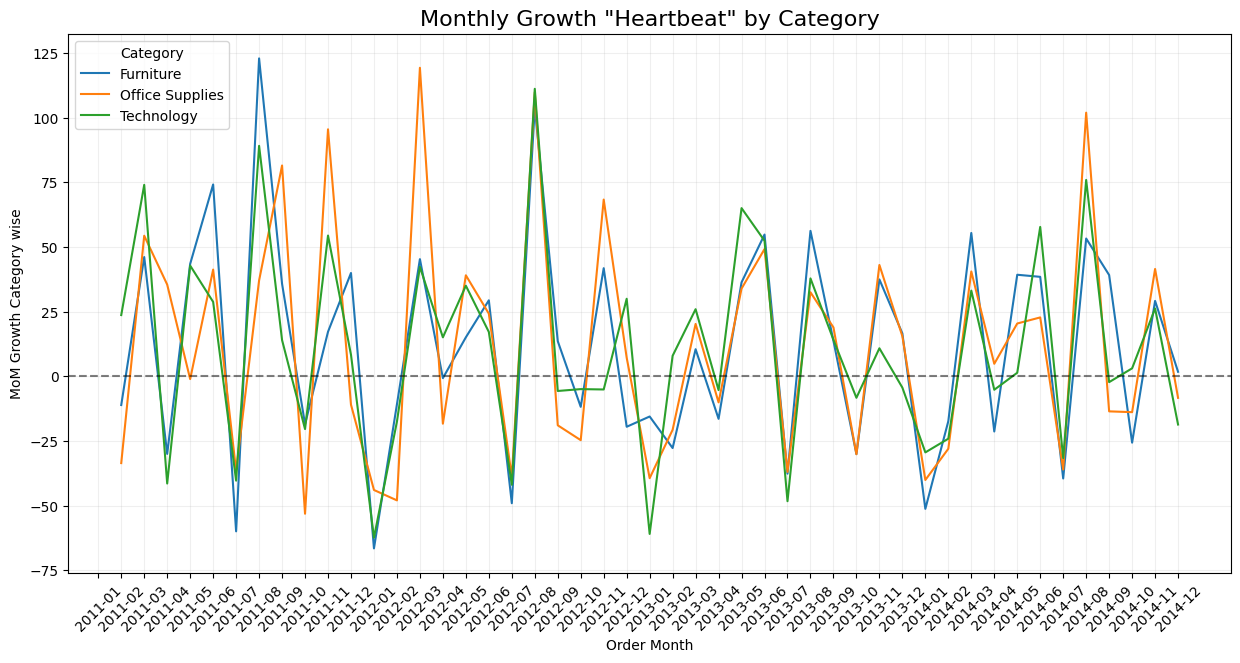

In [22]:
# Convert Period to a format the graph understands
category_monthly['Order Month'] = category_monthly['Order Month'].astype(str)

# Now run the plot code again
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (15, 7)
sns.lineplot(data=category_monthly, x='Order Month', y='MoM Growth Category wise', hue='Category')

plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.title('Monthly Growth "Heartbeat" by Category', fontsize=16)
plt.xticks(rotation=45) 
plt.grid(True, alpha=0.2)
plt.show()

In [23]:
# 1. Re-group to get both Sales and Profit
category_monthly = df.groupby(['Category', 'Order Month'])[['Sales', 'Profit']].sum().reset_index()

# 2. Since we re-created the table, we need to put the Growth % back in
category_monthly['MoM Growth Category wise'] = category_monthly.groupby('Category')['Sales'].pct_change() * 100

# 3. Now calculate the Profit Margin % (Profit / Sales)
category_monthly['Profit_Margin_%'] = (category_monthly['Profit'] / category_monthly['Sales']) * 100

# Let's look at the first few rows to confirm we have all 5 columns now
category_monthly

,Category,Order Month,Sales,Profit,MoM Growth Category wise,Profit_Margin_%
0,Furniture,2011-01,34463.75300,691.20090,NaN,2.005588
1,Furniture,2011-02,30641.20350,2878.62080,-11.091507,9.394607
2,Furniture,2011-03,44780.13880,4888.28780,46.143538,10.916196
3,Furniture,2011-04,31344.86510,2085.53820,-30.002751,6.653524
4,Furniture,2011-05,44980.66830,546.02370,43.502510,1.213907
5,Furniture,2011-06,78368.85210,3885.92180,74.227852,4.958503
6,Furniture,2011-07,31385.19320,864.50890,-59.951955,2.754512
7,Furniture,2011-08,69984.45920,723.08440,122.985593,1.033207
8,Furniture,2011-09,95029.12170,10419.24850,35.786034,10.964269
9,Furniture,2011-10,77411.70410,9262.45160,-18.538967,11.965182


In [24]:
category_summary = category_monthly.groupby("Category").agg({"MoM Growth Category wise":["min","max","mean"], "Profit_Margin_%":["max","min","mean"]})
category_summary = category_summary.round(2)
category_summary

MoM Growth Category wise                Profit_Margin_%        \
                                     min     max   mean             max   min   
Category                                                                        
Furniture                         -66.55  122.99  11.73           13.23 -4.38   
Office Supplies                   -53.14  119.36  11.79           19.98  2.30   
Technology                        -62.40  111.22  11.07           18.84  6.02   

                        
                  mean  
Category                
Furniture         6.68  
Office Supplies  13.59  
Technology       13.82

In [25]:
# Find best perferming and worst performing months by Profit margin
best_month = category_monthly.loc[category_monthly.groupby("Category")["Profit_Margin_%"].idxmax()]
worst_month = category_monthly.loc[category_monthly.groupby("Category")["Profit_Margin_%"].idxmin()]

print(" ------- Best Perferming Month ------")
best_month

 ------- Best Perferming Month ------


,Category,Order Month,Sales,Profit,MoM Growth Category wise,Profit_Margin_%
24,Furniture,2013-01,81804.60070,10821.45840,-15.531220,13.228423
83,Office Supplies,2013-12,127926.20950,25563.49140,15.523828,19.982998
97,Technology,2011-02,38233.95448,7203.10018,23.702421,18.839537


In [26]:

print(" ------- Worst Perferming Month ------")
worst_month

 ------- Worst Perferming Month ------


,Category,Order Month,Sales,Profit,MoM Growth Category wise,Profit_Margin_%
12,Furniture,2012-01,42498.86140,-1861.76020,-66.548198,-4.380730
54,Office Supplies,2011-07,41358.63900,953.27380,-36.517563,2.304896
98,Technology,2011-03,66554.09466,4003.85226,74.070654,6.015937


In [30]:
# Now we need to find corelation bw MoM Sales Growth and Profit marfin %
corelation = category_monthly.groupby("Category")[["MoM Growth Category wise","Profit_Margin_%"]].corr().iloc[0::2, -1]
corelation

Category                                 
Furniture        MoM Growth Category wise    0.014319
Office Supplies  MoM Growth Category wise    0.201468
Technology       MoM Growth Category wise    0.182846
Name: Profit_Margin_%, dtype: float64

In [34]:
# Now lets see how many times we can see the negative Profit
loss_count = category_monthly[category_monthly["Profit"]<0].groupby("Category")["Profit"].count()
print(loss_count)

Category
Furniture    1
Name: Profit, dtype: int64


In [35]:
# Export to CSV for Tableau
category_monthly.to_csv("Category_Monthly_Analysis.csv", index=False)
print("File saved! You are ready for Tableau.")

File saved! You are ready for Tableau.
